# Linear Regression Assignment
## Medina County Career Center — AI/ML

**Your task:** Build a linear regression model from scratch using one of the datasets below.

You've seen the full process in the Auto MPG class example. Now it's your turn!

---

### Choose Your Dataset

Pick ONE of these UCI datasets. Each has a different prediction target:

| Dataset | UCI ID | What You Predict | Rows | Features | Difficulty |
|---------|--------|------------------|------|----------|------------|
| **Wine Quality** | 186 | Quality score (1-10) | 4,898 | 12 | Medium |
| **Real Estate Valuation** | 477 | House price per unit area | 414 | 6 | Easy |
| **Abalone** | 1 | Age (number of rings) | 4,177 | 8 | Medium |

---

### The Steps (follow this structure)

1. Install + import libraries
2. Load your chosen dataset from UCI
3. Explore: check shape, columns, missing values, and clean the data
4. Calculate correlations with your target variable
5. Make the correlation heatmap — **look for multicollinearity!**
6. Decide which features to keep unless the data guide has a suggestion about the variables - then follow that (or experiment)
7. Make at least ONE scatter plot of your strongest feature vs the target
8. Train/test split (80/20)
9. Build and train a LinearRegression model
10. Evaluate: print R² and MAE
11. Show the coefficients — interpret what the model learned
12. Make an actual vs predicted scatter plot

### Quick Reference — Copy and Adapt These Patterns

You don't need to switch back to the example notebook. Here are the code patterns for each step — just change the variable names and values to fit your dataset.

```python
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from ucimlrepo import fetch_ucirepo

# --- LOAD ---
dataset = fetch_ucirepo(id=___)          # replace ___ with your UCI ID
X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)

# --- EXPLORE + CLEAN ---
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
df = df.dropna()

# --- CORRELATIONS ---
corrMatrix = df.corr()
targetCorr = corrMatrix['your_target'].drop('your_target').sort_values()
print(targetCorr)

# --- HEATMAP ---
plt.figure(figsize=(9, 7))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# --- FEATURE SELECTION (if dropping columns) ---
df = df.drop(columns=['col1', 'col2'])   # drop what you don't want
X = df.drop('your_target', axis=1)
y = df['your_target']

# --- SCATTER PLOT ---
plt.figure(figsize=(8, 5))
plt.scatter(df['best_feature'], df['your_target'], alpha=0.5)
plt.xlabel('Best Feature')
plt.ylabel('Target')
plt.title('Best Feature vs Target')
plt.show()

# --- SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- BUILD + TRAIN ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- EVALUATE ---
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print(f'R² = {r2:.4f}, MAE = {mae:.2f}')

# --- COEFFICIENTS ---
coeffDf = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coeffDf = coeffDf.sort_values('Coefficient', key=abs, ascending=False)
print(coeffDf)
print(f'Intercept: {model.intercept_:.2f}')

# --- ACTUAL vs PREDICTED ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
minVal = min(y_test.min(), predictions.min())
maxVal = max(y_test.max(), predictions.max())
plt.plot([minVal, maxVal], [minVal, maxVal], 'r--', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()
```

## Step 1: Install + Import Libraries

In [ ]:
!pip install ucimlrepo -q

In [1]:
# Import your libraries here
# Hint: you need pandas, numpy, matplotlib, seaborn, sklearn stuff, ucimlrepo
# Look at the class example to get the right stuff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from ucimlrepo import fetch_ucirepo


## Step 2: Load Your Dataset

Use `fetch_ucirepo(id=___)` with the ID number from the table above.

Then get X (features) and y (target).

In [6]:
# Load your chosen dataset
# Example: dataset = fetch_ucirepo(id=186)  # for Wine Quality
dataset = fetch_ucirepo(id=477)
X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)


## Step 3: Explore the Data

Print the shape, column names, first few rows, and check for missing values.

In [7]:
# Explore your data here
# - How many rows and columns?
# - What are the column names?
# - Any missing values? If so, drop them.

# We didn't use this example in our walktrhough, so providing a code snippet that 
print(f'Dtypes:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')

# Some of your variables might be categorical - there are ways to deal with this, but for this exercise we'll drop them
non_numeric = df.select_dtypes(exclude='number').columns.tolist()
if non_numeric:
    print(f'\nNon-numeric columns: {non_numeric}')
    for col in non_numeric:
        print(f'  {col} unique values: {df[col].unique()}')
    print(f'\nDropping non-numeric columns for linear regression')
    df = df.drop(columns=non_numeric)

print(f'\nRows before cleaning: {len(df)}')
df = df.dropna()
print(f'Rows after cleaning:  {len(df)}')

Dtypes:
X1 transaction date                       float64
X2 house age                              float64
X3 distance to the nearest MRT station    float64
X4 number of convenience stores             int64
X5 latitude                               float64
X6 longitude                              float64
Y house price of unit area                float64
dtype: object

Missing values:
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

Rows before cleaning: 414
Rows after cleaning:  414


## Step 4: Correlations

Calculate the Pearson r between each feature and your target. Which features have the strongest relationships?

In [11]:
# Calculate and print correlations with your target variable
corrMatrix = df.corr()
targetCorr = corrMatrix['Y house price of unit area'].drop('Y house price of unit area').sort_values()
print(targetCorr)


X3 distance to the nearest MRT station   -0.673613
X2 house age                             -0.210567
X1 transaction date                       0.087491
X6 longitude                              0.523287
X5 latitude                               0.546307
X4 number of convenience stores           0.571005
Name: Y house price of unit area, dtype: float64


## Step 5: Correlation Heatmap — Check for Multicollinearity!

Create the full correlation heatmap with ALL features. Look for:
- Which features correlate most strongly with your **target** (the thing you're predicting)?
- Which features correlate strongly with **each other**? That's multicollinearity — and you should think about whether to drop some of them.
- The rule of thumb (at least for our purposes) is if an independent variable (a predictor) has a Pearson r value of 0.7 or higher with the other variable, remove it from the model. 

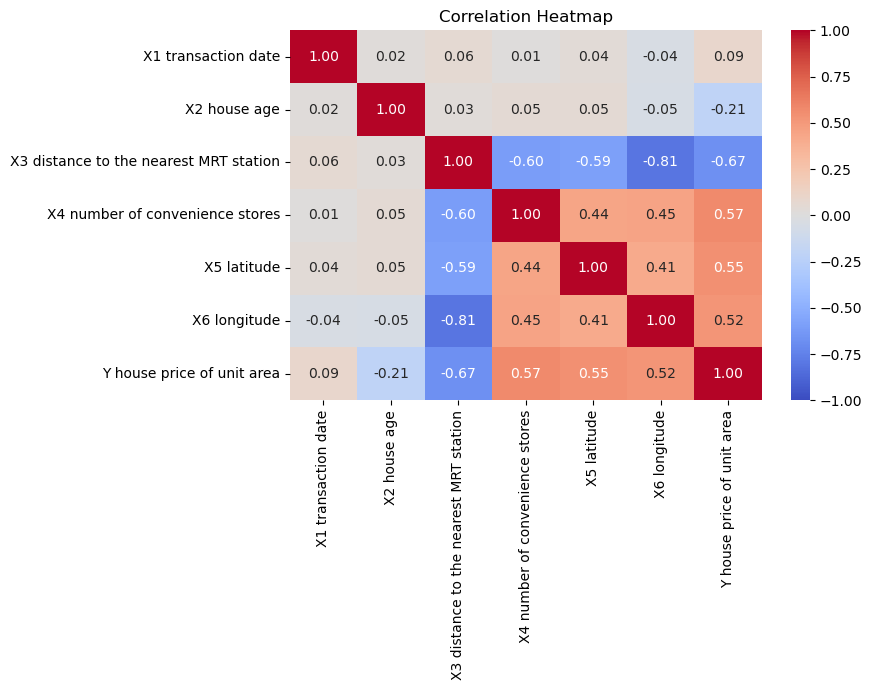

In [12]:
# Correlation heatmap — use ALL features before you decide what to drop
plt.figure(figsize=(9, 7))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 6: Feature Selection — What Are You Keeping?

Based on the heatmap and correlations, decide which features to include in your model. You have choices:
- **Use just one feature** (simple linear regression) — easiest to interpret
- **Use a few features** — but watch out for multicollinearity between them
- **Use all features** — might get a higher R², but coefficients may be hard to explain

**In the code cell below, drop any columns you've decided to remove. In the markdown cell after that, explain WHY you made that choice.** There's no single right answer — just show that you thought about it.

In [23]:
# Drop any features you don't want to include (if any)
# Example: df = df.drop(columns=['feature1', 'feature2'])
# Then update X and y:
# X = df.drop('your_target', axis=1)
# y = df['your_target']
X = df.drop('Y house price of unit area', axis=1)
y = df['Y house price of unit area']


**My feature selection decision:** *(explain here — what did you keep, what did you drop, and why?)*

The heat map displayed solid correlation between a lot of features and as there are only a few features, keeping them all is likely the best decision. 


## Step 7: Scatter Plot

Create a scatter plot showing your strongest-correlated feature vs the target.

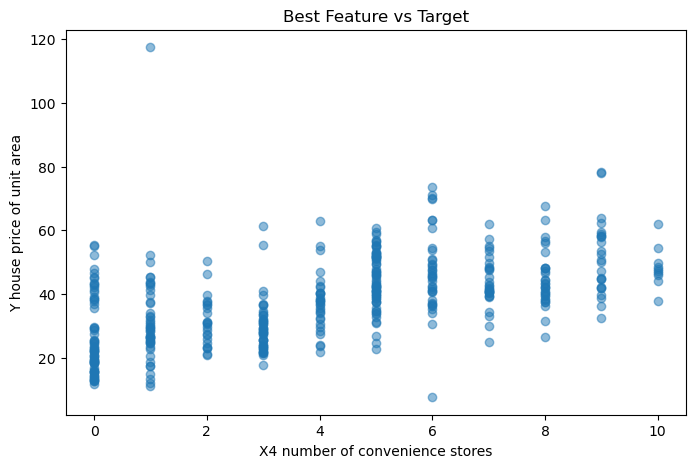

In [24]:
# Scatter plot: strongest feature vs target
plt.figure(figsize=(8, 5))
plt.scatter(df['X4 number of convenience stores'], df['Y house price of unit area'], alpha=0.5)
plt.xlabel('X4 number of convenience stores')
plt.ylabel('Y house price of unit area')
plt.title('Best Feature vs Target')
plt.show()


## Step 8: Train/Test Split

In [25]:
# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Step 9: Build and Train the Model

In [26]:
# Create a LinearRegression model and fit it
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Step 10: Evaluate

Print R² and MAE. Write a sentence interpreting what they mean for your dataset.

In [27]:
# Make predictions on test data and calculate R² and MAE
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print(f'R² = {r2:.4f}, MAE = {mae:.2f}')


R² = 0.6811, MAE = 5.31


## Step 11: Coefficients

Display the coefficients. Which features have the biggest effect? Are they positive or negative? Do any of the signs surprise you? (Remember what we saw with multicollinearity in the class example.)

In [28]:
# Show coefficients and interpret them
coeffDf = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coeffDf = coeffDf.sort_values('Coefficient', key=abs, ascending=False)
print(coeffDf)
print(f'Intercept: {model.intercept_:.2f}')


                                  Feature  Coefficient
4                             X5 latitude   229.043054
5                            X6 longitude   -29.492591
0                     X1 transaction date     5.440742
3         X4 number of convenience stores     1.091425
1                            X2 house age    -0.270791
2  X3 distance to the nearest MRT station    -0.004759
Intercept: -13044.23


## Step 12: Actual vs Predicted Plot

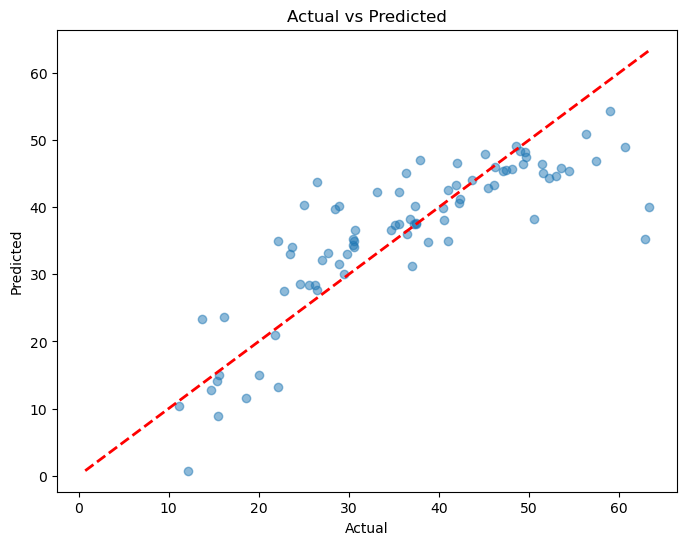

In [29]:
# Scatter plot: actual vs predicted with the red dashed "perfect" line
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
minVal = min(y_test.min(), predictions.min())
maxVal = max(y_test.max(), predictions.max())
plt.plot([minVal, maxVal], [minVal, maxVal], 'r--', linewidth=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()


## Reflection (answer in this cell)

1. What dataset did you choose and why?
2. What was your R² score? Do you think that is good or bad, considering your dataset?
3. Which feature had the strongest correlation with your target?
4. Did you see any multicollinearity in your heatmap? What did you do about it — did you drop any features? Why or why not?
5. Look at your coefficients — do any of the signs (positive/negative) surprise you or seem to contradict what you'd expect? If so, what might explain that?
6. If you wanted to improve this model, what would you try next?

In [30]:
1. I chose the Taiwanese property value data set as it was the easiest difficulty and I do not have much experience with machine learning
2. My value was 0.6811, which was good as my dataset did not have many variables to train on
3. The distance to an MRT Station had the strongest correlation
4. I did not drop any features as the dataset had an extremely small set of variables
5. None of the coefficients contradict what I'd expect
6. To improve this model, I would add significantly more features

SyntaxError: unterminated string literal (detected at line 5) (552633043.py, line 5)